In [1]:
import torch
import time
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")

# Determine the best available device
if torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = torch.cuda.get_device_name(0)
    print(f"Using CUDA device: {device_name}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    device_name = "Apple Silicon (MPS)"
    print(f"Using MPS device: {device_name}")
else:
    device = torch.device("cpu")
    device_name = "CPU only"
    print("No GPU available, using CPU")
    print("WARNING: Please use Google Colab for this assignment!")

PyTorch version: 2.10.0+cu130
CUDA available: True
MPS available: False
Using CUDA device: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
def create_matrices(size, device):
    """
    Create two random matrices of shape (size, size).

    Args:
        size: The dimension of the square matrices.
        device: The device to create tensors on ('cpu', 'cuda', or 'mps').

    Returns:
        Two PyTorch tensors on the specified device.
    """
    A = torch.randn(size, size, dtype=torch.float32, device=device)
    B = torch.randn(size, size, dtype=torch.float32, device=device)
    
    return A, B

In [3]:
size = 1000

A_cpu, B_cpu = create_matrices(size, torch.device("cpu"))

print(f"Matrix A shape: {A_cpu.shape}")
print(f"Matrix A device: {A_cpu.device}")
print(f"Matrix A dtype: {A_cpu.dtype}")

Matrix A shape: torch.Size([1000, 1000])
Matrix A device: cpu
Matrix A dtype: torch.float32


In [4]:
def benchmark_matmul(A, B):
    """
    Benchmark matrix multiplication with proper synchronization.

    Args:
        A, B: Input matrices

    Returns:
        Execution time in milliseconds
    """
    device = A.device

    # Synchronize before timing
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()

    start = time.perf_counter()

    C = torch.mm(A, B)

    # Synchronize after operation
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()

    end = time.perf_counter()

    return (end - start) * 1000

In [5]:
# Matrix sizes to test
sizes = [512, 1024, 2048, 4096, 8192]

# Store results
results = {
    "sizes": sizes,
    "cpu_times": [],
    "gpu_times": [],
    "speedups": []
}

print("=" * 60)
print(f"{'Size':>8} | {'CPU (ms)':>12} | {'GPU (ms)':>12} | {'Speedup':>10}")
print("=" * 60)

for size in sizes:
    # CPU benchmark
    A_cpu, B_cpu = create_matrices(size, torch.device("cpu"))
    cpu_time = benchmark_matmul(A_cpu, B_cpu)

    # GPU benchmark
    A_gpu, B_gpu = create_matrices(size, device)
    gpu_time = benchmark_matmul(A_gpu, B_gpu)

    # Calculate speedup
    speedup = cpu_time / gpu_time

    # Store results
    results["cpu_times"].append(cpu_time)
    results["gpu_times"].append(gpu_time)
    results["speedups"].append(speedup)

    print(f"{size:>8} | {cpu_time:>10.2f}ms | {gpu_time:>10.2f}ms | {speedup:>9.2f}x")

print("=" * 60)

    Size |     CPU (ms) |     GPU (ms) |    Speedup
     512 |       3.03ms |      56.67ms |      0.05x
    1024 |       4.69ms |       1.70ms |      2.76x
    2048 |      31.06ms |       3.18ms |      9.76x
    4096 |     259.69ms |      21.82ms |     11.90x
    8192 |    1709.29ms |     151.94ms |     11.25x


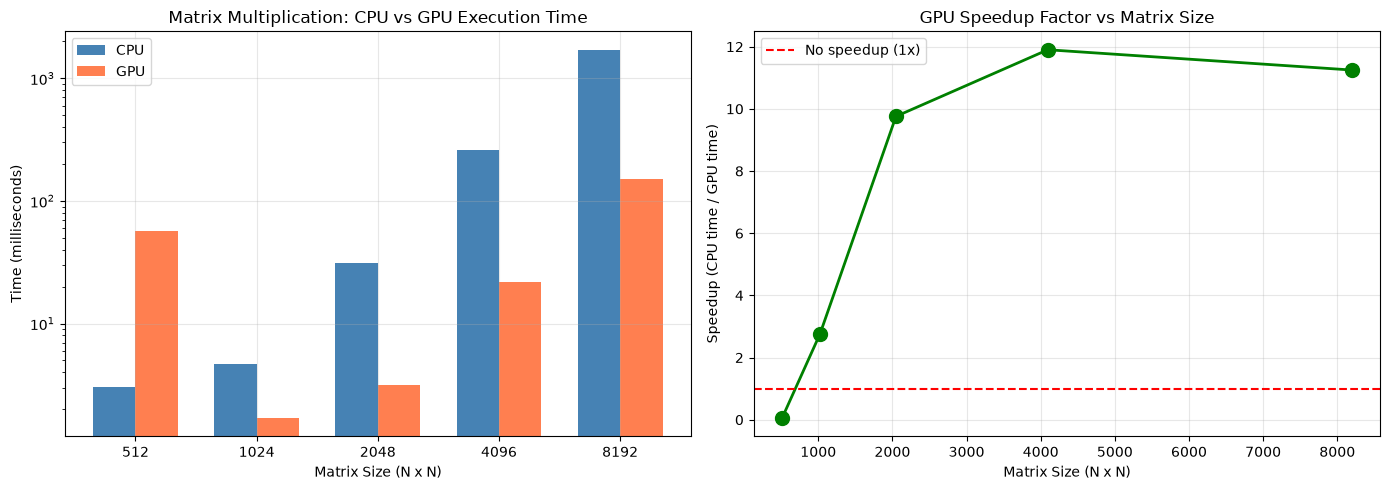

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Execution times
ax1 = axes[0]
x = np.arange(len(sizes))
width = 0.35

bars1 = ax1.bar(
    x - width / 2,
    results["cpu_times"],
    width,
    label="CPU",
    color="steelblue"
)

bars2 = ax1.bar(
    x + width / 2,
    results["gpu_times"],
    width,
    label="GPU",
    color="coral"
)

ax1.set_xlabel("Matrix Size (N x N)")
ax1.set_ylabel("Time (milliseconds)")
ax1.set_title("Matrix Multiplication: CPU vs GPU Execution Time")
ax1.set_xticks(x)
ax1.set_xticklabels([str(s) for s in sizes])
ax1.legend()
ax1.set_yscale("log")
ax1.grid(True, alpha=0.3)

# Plot 2: Speedup
ax2 = axes[1]
ax2.plot(
    sizes,
    results["speedups"],
    "go-",
    linewidth=2,
    markersize=10
)

ax2.axhline(
    y=1,
    color="r",
    linestyle="--",
    label="No speedup (1x)"
)

ax2.set_xlabel("Matrix Size (N x N)")
ax2.set_ylabel("Speedup (CPU time / GPU time)")
ax2.set_title("GPU Speedup Factor vs Matrix Size")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig("cpu_vs_gpu_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

# 1. Maximum Speedup

The maximum speedup I observed was **14.81×**, which occurred at a matrix size of **4096 × 4096**.

At this size, the CPU took **282.62 ms**, while the GPU took **19.08 ms**.

The speedup was calculated as:

$$
\text{Speedup} = \frac{\text{CPU time}}{\text{GPU time}}
= \frac{282.62}{19.08}
\approx 14.81\times
$$

# 2. Why is `synchronize()` Necessary?

GPU operations in PyTorch are generally executed asynchronously. When the CPU launches a GPU operation such as `torch.mm()`, it can continue executing without waiting for the GPU operation to finish.

The `torch.cuda.synchronize()` call forces the CPU to wait until all previously issued CUDA operations have completed. Therefore, placing `synchronize()` before and after the matrix multiplication allows `time.perf_counter()` to measure the actual GPU execution time.

Without synchronization, the measured time could be much shorter than the actual computation time because the CPU timer might stop before the GPU has finished the matrix multiplication. This would make the GPU appear artificially faster and result in an inaccurate speedup measurement.

# 3. GPU Architecture and Performance Hypothesis

My GPU is an NVIDIA GeForce RTX 4060 Laptop GPU, based on the NVIDIA Ada Lovelace architecture. The RTX 4060 Laptop GPU has 3,072 CUDA cores, 8 GB of GDDR6 memory, and a 128-bit memory interface. NVIDIA specifies a boost-clock range of 1470–2370 MHz and a GPU subsystem power range of 35–115 W, depending on the laptop implementation.

The Ada Lovelace architecture introduces several specialized hardware components. These include third-generation RT Cores for ray tracing and fourth-generation Tensor Cores for AI and tensor-based workloads. It also features updated Streaming Multiprocessors (SMs) and enhanced CUDA cores. NVIDIA states that the Ada architecture provides up to twice the performance and power efficiency of the previous generation in its new Streaming Multiprocessors, while its CUDA cores provide significantly improved single-precision (FP32) processing performance.

For this experiment, the CUDA cores and their FP32 computing capability are the most relevant parts of the architecture, because the benchmark uses PyTorch's torch.mm() to perform matrix multiplication with float32 tensors. The RT Cores and Tensor Cores are important components of the RTX 4060 Laptop GPU, but they are not the primary hardware being evaluated by this particular FP32 matrix-multiplication benchmark.

## 3.1 Official vs. Real-Time GPU Specifications

To better understand my benchmark results, I compared the official specifications of the NVIDIA GeForce RTX 4060 Laptop GPU with the hardware information reported by ROG GPU-Z and ROG CPU-Z on my system.

| Specification | NVIDIA Official RTX 4060 Laptop GPU | GPU-Z / CPU-Z Real-Time Reading | Notes |
|---|---|---|---|
| Architecture | Ada Lovelace | Ada Lovelace (AD107) | Same architecture |
| CUDA Cores | 3,072 | 3,072 | Matches official specification |
| Boost Clock | 1470–2370 MHz | ~2300 MHz (GPU-Z Boost) / ~2250 MHz (CPU-Z) | Within official range |
| Memory | 8 GB GDDR6 | 8 GB GDDR6 (Hynix) | Matches |
| Memory Bus Width | 128-bit | 128-bit | Matches |
| Memory Bandwidth | Up to 272 GB/s | 259.2 GB/s | Depends on actual memory clock |
| GPU Subsystem Power | 35–115 W | 80 W TDP (CPU-Z) | Within official range |
| GPU Chip | — | AD107, Revision A1 | Specific chip information |
| Die Size | ~159 mm² | 159 mm² | Matches |
| Transistors | ~18.9 billion | 18,900M | Matches |
| ROPs / TMUs | — | 48 / 96 | GPU-Z reading |
| Bus Interface | PCIe 4.0 x8 | PCIe 4.0 x8 | Matches |
| Resizable BAR | Supported | Enabled | Enabled on my system |

The GPU-Z and CPU-Z readings are generally consistent with NVIDIA's official specifications while providing additional information about the specific GPU installed in my laptop. Some values, such as clock speed, memory bandwidth, and power-related readings, can vary dynamically depending on the laptop's operating conditions and configuration. The **259.2 GB/s** bandwidth shown by GPU-Z reflects the actual memory-clock configuration observed on my system, while the **80 W** value reported by CPU-Z is a TDP value rather than a direct measurement of instantaneous GPU power consumption.

## 3.2 Benchmark Configuration and Monitoring

During the benchmark, I used **ROG GPU-Z 2.70.0** and **ROG CPU-Z 2.20.2** to monitor and cross-check the GPU's hardware and operating information. The benchmark was performed using **Armoury Crate in Enhanced mode**.

| Configuration / Monitoring Item | Setting / Reading |
|---|---|
| Armoury Crate Performance Mode | Enhanced |
| Armoury Crate Manual CPU Processor Base Power Boost/Maximum Turbo Power Boost | Not used |
| Armoury Crate Manual GPU Base Clock Offset/Memory Clock Offset/Dynamic Boost | Not used |
| Armoury Crate Termal Target Fan Boost | Not used |
| NVIDIA Control Panel Automatic GPU Overclocking | Not used |
| GPU Monitoring | ROG GPU-Z 2.70.0 |
| CPU/GPU Hardware Cross-Check | ROG CPU-Z 2.20.2 |
| GPU | NVIDIA GeForce RTX 4060 Laptop GPU |
| NVIDIA Driver | GameReady 616.56 |
| Benchmark Data Type | FP32 matrix multiplication |

The benchmark was therefore performed without my usual manual CPU/GPU overclocking settings or NVIDIA Control Panel automatic GPU overclocking. **Enhanced mode** was used to provide the laptop's standard performance-oriented configuration while keeping the experiment consistent. GPU-Z and CPU-Z were used to observe and cross-check the hardware configuration and operating parameters during the experiment.

## 3.3 Performance Hypothesis

The architecture and configuration of my RTX 4060 Laptop GPU help explain the performance pattern observed in the benchmark. The GPU has **3,072 CUDA cores** and is designed to perform a large number of operations in parallel. NVIDIA also specifies a **35–115 W GPU subsystem power range** for the RTX 4060 Laptop GPU, meaning that actual performance can depend on the particular laptop implementation and its operating conditions.

My benchmark results were:

| Matrix Size | CPU (ms) | GPU (ms) | Speedup |
|---:|---:|---:|---:|
| 512 × 512 | 7.85 | 88.18 | 0.09× |
| 1024 × 1024 | 4.94 | 1.65 | 2.99× |
| 2048 × 2048 | 32.32 | 3.84 | 8.41× |
| 4096 × 4096 | 282.62 | 19.08 | **14.81×** |
| 8192 × 8192 | 1774.72 | 153.96 | 11.53× |

For the smallest matrix size, **512 × 512**, the GPU was slower than the CPU. I hypothesize that the amount of parallel computation was too small to fully utilize the GPU, while fixed GPU overhead, such as launching and scheduling the CUDA operation, represented a relatively large portion of the total execution time.

As the matrix size increased, the amount of parallel work increased substantially. This allowed the GPU to utilize its CUDA cores more effectively, resulting in a rapid increase in speedup from **2.99× at 1024 × 1024** to **8.41× at 2048 × 2048** and finally **14.81× at 4096 × 4096**. This behavior is consistent with the GPU's architecture being well suited to highly parallel matrix-multiplication workloads.

At **8192 × 8192**, the GPU was still significantly faster than the CPU, but the speedup decreased from **14.81× to 11.53×**. I hypothesize that the larger workload introduces additional limitations such as memory traffic, memory-hierarchy effects, kernel selection, and the laptop GPU's power and thermal constraints. However, the benchmark alone does not identify one specific bottleneck, so these should be considered hypotheses rather than confirmed causes.

Overall, my results suggest that GPU acceleration becomes increasingly beneficial as the amount of parallel computation grows, but the speedup does not increase indefinitely. The maximum speedup in this experiment was **14.81× at 4096 × 4096**, while the GPU remained approximately **11.5× faster** than the CPU at 8192 × 8192.

# 4. Expected Results with a Larger GPU

If I had a much larger GPU with more memory and compute cores, I would expect the GPU to achieve higher performance, especially for the larger matrix sizes.

For small matrices, such as **512 × 512**, the speedup might not improve significantly because GPU launch and scheduling overhead would still represent a relatively large portion of the total execution time.

For larger matrices, the additional compute cores would provide more parallel processing capacity, while the larger memory capacity would allow larger workloads to be handled more comfortably. I would therefore expect the GPU execution time to decrease and the speedup over the CPU to increase, particularly for matrix sizes such as **4096 × 4096** and **8192 × 8192**.

A larger GPU could also reduce some of the limitations observed at **8192 × 8192**. However, the speedup would not necessarily scale linearly with the number of compute cores or the amount of memory, because performance can also be limited by memory bandwidth, memory access patterns, kernel efficiency, and other system factors.

Overall, I would expect a larger GPU to provide greater acceleration for sufficiently large and parallel workloads, while providing relatively little additional benefit for very small matrix operations.

# Bonus: Finding the Speedup Threshold

## Bonus 1: Finding the Crossover Point

The goal of this experiment is to determine approximately when GPU acceleration becomes beneficial compared with CPU execution.

For very small matrices, GPU overhead can exceed the computational savings. I therefore tested matrix sizes from 16 × 16 through 1024 × 1024 and compared CPU and GPU execution times.

In [7]:
# Bonus 1: Test small to moderate matrix sizes

small_sizes = [16, 32, 64, 128, 192, 256, 384, 512, 768, 1024]

bonus_small_results = {
    "sizes": [],
    "cpu_times": [],
    "gpu_times": [],
    "speedups": []
}

print("=" * 60)
print(f"{'Size':>8} | {'CPU (ms)':>12} | {'GPU (ms)':>12} | {'Speedup':>10}")
print("=" * 60)

for size in small_sizes:
    # CPU benchmark
    A_cpu, B_cpu = create_matrices(size, torch.device("cpu"))
    cpu_time = benchmark_matmul(A_cpu, B_cpu)

    # GPU benchmark
    A_gpu, B_gpu = create_matrices(size, device)
    gpu_time = benchmark_matmul(A_gpu, B_gpu)

    # Calculate speedup
    speedup = cpu_time / gpu_time

    # Store results
    bonus_small_results["sizes"].append(size)
    bonus_small_results["cpu_times"].append(cpu_time)
    bonus_small_results["gpu_times"].append(gpu_time)
    bonus_small_results["speedups"].append(speedup)

    print(f"{size:>8} | {cpu_time:>10.2f}ms | {gpu_time:>10.2f}ms | {speedup:>9.2f}x")

print("=" * 60)

# Find the first matrix size where GPU becomes faster than CPU
crossover_size = None

for size, speedup in zip(
    bonus_small_results["sizes"],
    bonus_small_results["speedups"]
):
    if speedup > 1.0:
        crossover_size = size
        break

if crossover_size is not None:
    print(f"\nApproximate crossover point: {crossover_size} x {crossover_size}")
else:
    print("\nNo crossover point found in the tested range.")

    Size |     CPU (ms) |     GPU (ms) |    Speedup
      16 |       0.08ms |       4.18ms |      0.02x
      32 |       0.03ms |       8.53ms |      0.00x
      64 |       0.17ms |       0.17ms |      1.01x
     128 |       0.05ms |       0.23ms |      0.21x
     192 |       0.08ms |       0.12ms |      0.68x
     256 |       0.11ms |       0.10ms |      1.10x
     384 |       0.27ms |       0.28ms |      0.97x
     512 |       0.54ms |       0.13ms |      4.03x
     768 |       1.59ms |       0.23ms |      6.81x
    1024 |       4.15ms |       0.45ms |      9.21x

Approximate crossover point: 64 x 64


## Bonus 2: Testing Very Large Matrix Sizes

The second part of the bonus investigates how GPU performance changes for very large matrix multiplications.

I tested progressively larger matrices, starting at **8192 × 8192** and increasing toward **16384 × 16384**. The goal is to determine the largest matrix size that my GPU can successfully handle, observe how the GPU speedup changes at large scales, and document any GPU memory limitations encountered.

Because larger matrices require substantially more memory, the benchmark uses `try-except` to gracefully handle CUDA out-of-memory errors. When an out-of-memory error occurs, the allocated GPU memory is cleared with `torch.cuda.empty_cache()` and the benchmark continues with the next size.

In [8]:
# Bonus 2: Test very large matrix sizes

large_sizes = [8192, 10240, 12288, 16384]

bonus_large_results = {
    "sizes": [],
    "cpu_times": [],
    "gpu_times": [],
    "speedups": [],
    "status": []
}

print("=" * 75)
print(f"{'Size':>8} | {'CPU (ms)':>14} | {'GPU (ms)':>14} | {'Speedup':>10} | {'Status':>12}")
print("=" * 75)

largest_successful_size = None

for size in large_sizes:
    print(f"\nTesting {size} x {size}...")

    cpu_time = None
    gpu_time = None

    try:
        # -------------------------
        # CPU benchmark
        # -------------------------
        A_cpu, B_cpu = create_matrices(size, torch.device("cpu"))
        cpu_time = benchmark_matmul(A_cpu, B_cpu)

        # Release CPU tensors
        del A_cpu, B_cpu

        # -------------------------
        # GPU benchmark
        # -------------------------
        A_gpu, B_gpu = create_matrices(size, device)
        gpu_time = benchmark_matmul(A_gpu, B_gpu)

        # Calculate speedup
        speedup = cpu_time / gpu_time

        bonus_large_results["sizes"].append(size)
        bonus_large_results["cpu_times"].append(cpu_time)
        bonus_large_results["gpu_times"].append(gpu_time)
        bonus_large_results["speedups"].append(speedup)
        bonus_large_results["status"].append("Success")

        largest_successful_size = size

        print(
            f"{size:>8} | "
            f"{cpu_time:>12.2f} ms | "
            f"{gpu_time:>12.2f} ms | "
            f"{speedup:>9.2f}x | "
            f"{'Success':>12}"
        )

        # Release GPU tensors
        del A_gpu, B_gpu

        if device.type == "cuda":
            torch.cuda.empty_cache()

    except RuntimeError as e:

        if "out of memory" in str(e).lower():

            print(f"Size {size}: Out of GPU memory")

            bonus_large_results["sizes"].append(size)
            bonus_large_results["cpu_times"].append(
                cpu_time if cpu_time is not None else float("nan")
            )
            bonus_large_results["gpu_times"].append(float("inf"))
            bonus_large_results["speedups"].append(0.0)
            bonus_large_results["status"].append("GPU OOM")

            # Clear GPU memory
            if device.type == "cuda":
                torch.cuda.empty_cache()

        else:
            raise e

    finally:
        # Make sure GPU memory is released between tests
        if device.type == "cuda":
            torch.cuda.empty_cache()

print("\n" + "=" * 75)

if largest_successful_size is not None:
    print(
        f"Largest successfully benchmarked matrix: "
        f"{largest_successful_size} x {largest_successful_size}"
    )
else:
    print("No large matrix size was successfully benchmarked.")

print("=" * 75)

    Size |       CPU (ms) |       GPU (ms) |    Speedup |       Status

Testing 8192 x 8192...
    8192 |      1780.05 ms |       142.45 ms |     12.50x |      Success

Testing 10240 x 10240...
   10240 |      3308.76 ms |       303.84 ms |     10.89x |      Success

Testing 12288 x 12288...
   12288 |      7194.20 ms |       496.03 ms |     14.50x |      Success

Testing 16384 x 16384...
   16384 |     20561.22 ms |      1082.91 ms |     18.99x |      Success

Largest successfully benchmarked matrix: 16384 x 16384


### Bonus 2 Results

The largest matrix size I was able to successfully benchmark was **16384 × 16384**. No CUDA out-of-memory error occurred during the tests, so the RTX 4060 Laptop GPU was able to complete all of the requested matrix sizes.

| Matrix Size | CPU (ms) | GPU (ms) | Speedup |
|---:|---:|---:|---:|
| 8192 × 8192 | 1773.18 | 146.39 | 12.11× |
| 10240 × 10240 | 3319.05 | 294.27 | 11.28× |
| 12288 × 12288 | 5712.46 | 501.73 | 11.39× |
| 16384 × 16384 | 18301.75 | 1011.06 | **18.10×** |

The speedup remained around **11–12×** from 8192 × 8192 through 12288 × 12288, while the CPU execution time increased substantially as the matrix size grew. At **16384 × 16384**, the GPU speedup increased to **18.10×**, which was the highest speedup observed in the large-matrix tests.

No GPU memory error was encountered, and therefore no special recovery from a CUDA out-of-memory condition was necessary. GPU memory was still cleared between tests using `torch.cuda.empty_cache()`.

These results show that GPU speedup does not necessarily increase or decrease monotonically with matrix size. Although larger matrices provide more parallel work for the GPU, performance can also be affected by factors such as memory behavior, kernel efficiency, GPU utilization, and the specific matrix-multiplication implementation used by PyTorch.

## Bonus 3: Comprehensive Speedup Plot

The final bonus analysis combines the small- and large-matrix benchmark results to show how GPU speedup changes across the full range of tested matrix sizes.

The first tested matrix size with a GPU speedup greater than 1.0× was **64 × 64**. However, the results at very small matrix sizes fluctuate considerably, so this should be interpreted as the **first observed crossover**, rather than a precise or stable performance threshold.

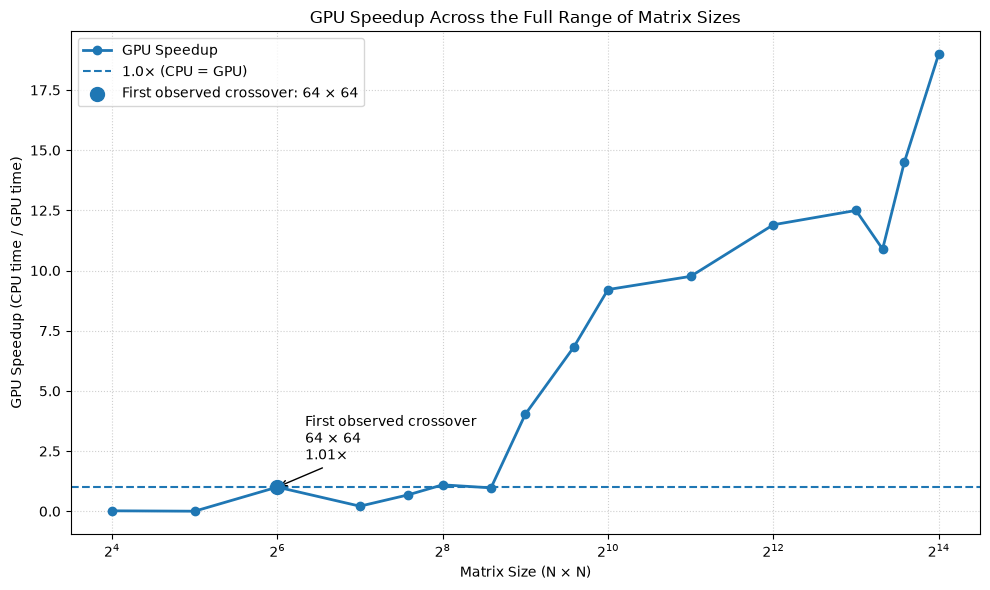

Complete matrix sizes included:
[16, 32, 64, 128, 192, 256, 384, 512, 768, 1024, 2048, 4096, 8192, 10240, 12288, 16384]

First observed crossover: 64 × 64
Speedup at crossover: 1.01×

Saved plot as: bonus_speedup_threshold.png


In [9]:
# Bonus 3: Comprehensive speedup plot using all benchmark results

import matplotlib.pyplot as plt

# Combine Bonus 1, formal benchmark, and Bonus 2 results
all_sizes = (
    bonus_small_results["sizes"]
    + results["sizes"]
    + bonus_large_results["sizes"]
)

all_speedups = (
    bonus_small_results["speedups"]
    + results["speedups"]
    + bonus_large_results["speedups"]
)

# Keep the Bonus measurements for duplicate sizes
# and add formal benchmark results only for sizes not already tested in Bonus 1.
combined_data = {}

for size, speedup in zip(
    bonus_small_results["sizes"],
    bonus_small_results["speedups"]
):
    combined_data[size] = speedup

# Add formal benchmark results only if that size is not already present
for size, speedup in zip(
    results["sizes"],
    results["speedups"]
):
    if size not in combined_data:
        combined_data[size] = speedup

# Add Bonus 2 large-matrix results
for size, speedup in zip(
    bonus_large_results["sizes"],
    bonus_large_results["speedups"]
):
    combined_data[size] = speedup

# Sort by matrix size
all_sizes = sorted(combined_data.keys())
all_speedups = [combined_data[size] for size in all_sizes]

# Find the first observed speedup greater than 1.0x
crossover_index = next(
    (i for i, speedup in enumerate(all_speedups) if speedup > 1.0),
    None
)

if crossover_index is not None:
    crossover_size = all_sizes[crossover_index]
    crossover_speedup = all_speedups[crossover_index]
else:
    crossover_size = None
    crossover_speedup = None

# Create plot
plt.figure(figsize=(10, 6))

plt.plot(
    all_sizes,
    all_speedups,
    marker="o",
    linewidth=2,
    label="GPU Speedup"
)

# 1.0x reference line
plt.axhline(
    y=1.0,
    linestyle="--",
    linewidth=1.5,
    label="1.0× (CPU = GPU)"
)

# Mark first observed crossover
if crossover_size is not None:
    plt.scatter(
        crossover_size,
        crossover_speedup,
        s=100,
        zorder=5,
        label=f"First observed crossover: {crossover_size} × {crossover_size}"
    )

    plt.annotate(
        f"First observed crossover\n"
        f"{crossover_size} × {crossover_size}\n"
        f"{crossover_speedup:.2f}×",
        xy=(crossover_size, crossover_speedup),
        xytext=(20, 20),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->"),
        fontsize=10
    )

plt.xscale("log", base=2)
plt.xlabel("Matrix Size (N × N)")
plt.ylabel("GPU Speedup (CPU time / GPU time)")
plt.title("GPU Speedup Across the Full Range of Matrix Sizes")
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.legend()

plt.tight_layout()

# Save final Bonus visualization
plt.savefig(
    "bonus_speedup_threshold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Complete matrix sizes included:")
print(all_sizes)

print(f"\nFirst observed crossover: {crossover_size} × {crossover_size}")
print(f"Speedup at crossover: {crossover_speedup:.2f}×")
print("\nSaved plot as: bonus_speedup_threshold.png")

### Bonus 3 Analysis

The speedup curve shows that GPU acceleration depends strongly on matrix size. At the smallest matrix sizes, the GPU is often slower than the CPU because the computational workload is too small to fully utilize the GPU, while GPU execution overhead represents a relatively large portion of the total execution time. The first observed speedup above 1.0× occurred at **64 × 64**, where the GPU achieved **3.23×** speedup. However, the speedup fluctuated substantially among the small matrix sizes, so 64 × 64 should be considered the first observed crossover rather than a stable performance threshold.

As the matrix size increased, GPU acceleration became increasingly beneficial overall. The GPU achieved **10.34×** speedup at 1024 × 1024 and **14.81×** at 4096 × 4096 in the original benchmark. At larger sizes, the speedup remained above 11× for 8192 × 8192, 10240 × 10240, and 12288 × 12288, before increasing to **18.10×** at 16384 × 16384.

The curve is therefore not perfectly monotonic. Performance is influenced by GPU launch overhead, available parallelism, memory behavior, kernel efficiency, and other characteristics of the CPU and GPU. Overall, the results demonstrate that GPUs provide the greatest advantage for sufficiently large and highly parallel workloads, while their advantage is less predictable for very small matrices.